# Model Building – Month 2, Lesson 2 Homework:
# Implement all learned algorithms using functions, klib and datacleaner analyze the results with Matplotlib, Seaborn, and Plotly Express.

In [80]:
import pandas as pd

In [81]:
df = pd.read_csv('AI Job Market Dataset.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

In [5]:
df.head()

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [6]:
df.isnull().sum()

job_id                  0
job_title               0
company_size            0
company_industry        0
country                 0
remote_type             0
experience_level        0
years_experience        0
education_level         0
skills_python           0
skills_sql              0
skills_ml               0
skills_deep_learning    0
skills_cloud            0
salary                  0
job_posting_month       0
job_posting_year        0
hiring_urgency          0
job_openings            0
dtype: int64

In [7]:
df.nunique()

job_id                  10345
job_title                   6
company_size                4
company_industry            6
country                     7
remote_type                 3
experience_level            3
years_experience           15
education_level             3
skills_python               2
skills_sql                  2
skills_ml                   2
skills_deep_learning        2
skills_cloud                2
salary                   9901
job_posting_month          12
job_posting_year            7
hiring_urgency              3
job_openings                9
dtype: int64

In [83]:
# Drop keraksiz ustunlarni 
df.drop('job_id', axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_title             10345 non-null  str  
 1   company_size          10345 non-null  str  
 2   company_industry      10345 non-null  str  
 3   country               10345 non-null  str  
 4   remote_type           10345 non-null  str  
 5   experience_level      10345 non-null  str  
 6   years_experience      10345 non-null  int64
 7   education_level       10345 non-null  str  
 8   skills_python         10345 non-null  int64
 9   skills_sql            10345 non-null  int64
 10  skills_ml             10345 non-null  int64
 11  skills_deep_learning  10345 non-null  int64
 12  skills_cloud          10345 non-null  int64
 13  salary                10345 non-null  int64
 14  job_posting_month     10345 non-null  int64
 15  job_posting_year      10345 non-null  int64
 16  hiring_urgency 

In [82]:
# Encoding 
from sklearn.preprocessing import LabelEncoder

def encodla(df):
    encoder = LabelEncoder()
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = encoder.fit_transform(df[col])
    return df
df = encodla(df)
        

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_title             10345 non-null  int64
 1   company_size          10345 non-null  int64
 2   company_industry      10345 non-null  int64
 3   country               10345 non-null  int64
 4   remote_type           10345 non-null  int64
 5   experience_level      10345 non-null  int64
 6   years_experience      10345 non-null  int64
 7   education_level       10345 non-null  int64
 8   skills_python         10345 non-null  int64
 9   skills_sql            10345 non-null  int64
 10  skills_ml             10345 non-null  int64
 11  skills_deep_learning  10345 non-null  int64
 12  skills_cloud          10345 non-null  int64
 13  salary                10345 non-null  int64
 14  job_posting_month     10345 non-null  int64
 15  job_posting_year      10345 non-null  int64
 16  hiring_urgency 

In [59]:
df.var()  # bu esa faqat hamma ustunlar numerical bolgnadagina ishalydi, sababi categorical uchun ishlamaydi variance

job_title               2.941674e+00
company_size            1.256029e+00
company_industry        2.950693e+00
country                 3.973898e+00
remote_type             6.701628e-01
experience_level        6.701628e-01
years_experience        1.866286e+01
education_level         6.589219e-01
skills_python           2.499764e-01
skills_sql              2.500149e-01
skills_ml               2.499621e-01
skills_deep_learning    2.500202e-01
skills_cloud            2.498929e-01
salary                  8.068470e+06
job_posting_month       1.206479e+01
job_posting_year        3.987432e+00
hiring_urgency          6.603446e-01
job_openings            6.676124e+00
dtype: float64

In [60]:
corr = df.corr()
   # aloqadorligini ko'rib berish uchun bazida encoding sabab kuchli bog'langanalr, kuchsiz bog'lanib qoladi
corr["salary"].sort_values(ascending=False)

salary                  1.000000
experience_level        0.642818
skills_deep_learning    0.234912
skills_ml               0.224209
skills_cloud            0.148313
skills_python           0.011949
company_industry        0.006889
job_openings            0.006735
job_posting_year        0.004029
remote_type             0.003177
education_level        -0.003586
skills_sql             -0.003863
job_title              -0.008920
years_experience       -0.011639
country                -0.013344
job_posting_month      -0.013852
company_size           -0.065949
hiring_urgency         -0.145502
Name: salary, dtype: float64

In [ ]:
"""
experience_level
skills_deep_learning
skills_ml
skills_cloud
company_size
hiring_urgency
years_experience
-- those are not much effective comptetetive level, so that we can drop them all
"""

In [61]:
df.drop(['experience_level', 'skills_deep_learning', 
'skills_ml','skills_cloud', 'company_size', 
'hiring_urgency', 'years_experience'],
axis=1, inplace=True)

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   job_title          10345 non-null  int64
 1   company_industry   10345 non-null  int64
 2   country            10345 non-null  int64
 3   remote_type        10345 non-null  int64
 4   education_level    10345 non-null  int64
 5   skills_python      10345 non-null  int64
 6   skills_sql         10345 non-null  int64
 7   salary             10345 non-null  int64
 8   job_posting_month  10345 non-null  int64
 9   job_posting_year   10345 non-null  int64
 10  job_openings       10345 non-null  int64
dtypes: int64(11)
memory usage: 889.2 KB


In [17]:
df.nunique()

job_title               6
company_industry        6
country                 7
remote_type             3
education_level         3
skills_python           2
skills_sql              2
salary               9901
job_posting_month      12
job_posting_year        7
job_openings            9
dtype: int64

# Scaling

In [84]:
from sklearn.preprocessing import MinMaxScaler

def do_scale(df):
    scaler = MinMaxScaler()
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = scaler.fit_transform(df[[col]])  # shu yerda 2 talik [[]]
    return df
df = do_scale(df)


In [63]:
df.head()

,job_title,company_industry,country,remote_type,education_level,skills_python,skills_sql,salary,job_posting_month,job_posting_year,job_openings
0,0.0,0.8,0.166667,1.0,0.5,0.0,0.0,0.907879,0.454545,0.666667,0.375
1,1.0,1.0,0.000000,0.0,0.0,1.0,1.0,0.932121,0.909091,1.000000,1.000
2,1.0,1.0,0.333333,0.5,0.5,1.0,0.0,0.909596,0.181818,1.000000,1.000
3,0.2,0.6,0.333333,1.0,0.5,0.0,1.0,0.311515,0.181818,0.833333,0.750
4,0.8,0.6,0.333333,0.0,0.5,1.0,1.0,0.483838,1.000000,0.166667,0.125


# Logistic Regression 

# train_test_split process 

In [64]:
# Here we can see the amount of something better not to do scaling
from sklearn.model_selection import train_test_split

x = df.drop('skills_python', axis=1)
y = df['skills_python']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state=42
)



In [19]:
x_train.shape

(7241, 10)

In [20]:
x_test.shape

(3104, 10)

In [21]:
y_train.shape

(7241,)

In [22]:
y_test.shape

(3104,)

In [85]:
# Model Selection
from sklearn.linear_model import LogisticRegression, LinearRegression

In [66]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [67]:
y_pred = lr.predict(x_test)


In [68]:
y_pred[0:5]

array([1., 0., 0., 0., 1.])

In [69]:
# Evaluation 
from sklearn.metrics import classification_report

In [70]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.53      0.52      1612
         1.0       0.48      0.48      0.48      1492

    accuracy                           0.50      3104
   macro avg       0.50      0.50      0.50      3104
weighted avg       0.50      0.50      0.50      3104



# Linear Regression 

In [86]:
lr_reg = LinearRegression()



In [87]:
x = df.drop('salary', axis=1)
y = df['salary'].astype(int)

In [88]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)


In [89]:
lr_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [90]:
y_pred = lr_reg.predict(x_test)

In [91]:
y_pred[0:10]

array([ 5.88211629e-04, -2.49393619e-04, -9.06544340e-04,  1.57481426e-04,
        6.47424674e-05,  4.97041093e-04,  9.04692909e-04,  3.62316683e-04,
        5.52678846e-04,  1.22103157e-04])

In [92]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [93]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)



0.0
0.0003588205224511927
1.9515376750087142e-07


# Decison Tree Classifier

In [94]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

In [95]:
dt_class = DecisionTreeClassifier()
dt_reg = DecisionTreeRegressor()

In [97]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('skills_python', axis=1)
y = df['skills_python']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [98]:
dt_class.fit(x_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [99]:
y_pred = dt_class.predict(x_test)

In [100]:
y_pred[0:10]

array([1., 0., 1., 1., 0., 1., 1., 1., 0., 1.])

In [101]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.48      0.50      1086
         1.0       0.47      0.51      0.49       983

    accuracy                           0.49      2069
   macro avg       0.50      0.50      0.49      2069
weighted avg       0.50      0.49      0.49      2069



# Decision Tree Regressor 

In [102]:
x = df.drop('salary', axis=1)
y = df['salary']

In [103]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [104]:
dt_reg.fit(x_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [105]:
y_pred = dt_reg.predict(x_test)

In [106]:
y_pred[0:10]

array([0.34131313, 0.13888889, 0.05181818, 0.22565657, 0.56363636,
       0.73424242, 0.54141414, 0.44191919, 0.10626263, 0.39151515])

In [107]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9808199805868983
0.030363030986520594
0.0015882491498657996


# Random Forest Classifier 

In [108]:
from sklearn.ensemble import RandomForestClassifier 

rf_class = RandomForestClassifier()

In [109]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('skills_python', axis=1)
y = df['skills_python']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [110]:
rf_class.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
y_pred = rf_class.predict(x_test)

In [112]:
y_pred[0:10]

array([1., 0., 1., 0., 0., 0., 1., 1., 0., 0.])

In [113]:
# Evaluation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.51      0.55      0.53      1086
         1.0       0.46      0.43      0.44       983

    accuracy                           0.49      2069
   macro avg       0.49      0.49      0.49      2069
weighted avg       0.49      0.49      0.49      2069



# Random Forest Regressor 

In [114]:
from sklearn.ensemble import RandomForestRegressor 

rf_reg = RandomForestRegressor()

In [115]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)


In [116]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)


0.9891452831795515
0.023728207156143363
0.0008988517889786353


# Support Vector Machine Classifier 

In [117]:
from sklearn.svm import SVC, SVR

In [ ]:
df.head()

,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,126,1024,3253,1,36,0,52,0,71,0,1306
1,450,22237,4569,1,15,0,50,0,131,0,2439
2,18,9308,4796,1,23,2,1,3,46,0,452
3,68,12786,4162,1,33,2,8,3,15,0,2024
4,406,972,686,0,1,2,8,3,188,0,1820


In [121]:
# Model train_test_split process
from sklearn.model_selection import train_test_split

x = df.drop('skills_python', axis=1)
y = df['skills_python']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [123]:
# # Bunda Scaling qilish juda muhim ekan sababi u ham huddi linearga o'xshab hyperline chizig'i bilan ajratiladi klaslar. Iloji boricha MinMaxScaler bilan qilgan maqul 
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# num_cols = df.select_dtypes(include=['int64']).columns.drop('skills_python')
# df[num_cols] = scaler.fit_transform(df[num_cols])

In [124]:
svc = SVC(kernel='linear', C=1.0, max_iter=2000)


In [125]:
svc.fit(x_train, y_train)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/sklearn/svm/_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=2000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [126]:
y_pred = svc.predict(x_test)

In [127]:
y_pred[0:10]

array([0., 0., 0., 1., 0., 1., 0., 1., 0., 1.])

In [128]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.42      0.46      1086
         1.0       0.47      0.58      0.52       983

    accuracy                           0.49      2069
   macro avg       0.50      0.50      0.49      2069
weighted avg       0.50      0.49      0.49      2069



# Support Vector Regressor

In [129]:
from sklearn.svm import SVR

In [130]:
svr = SVR(kernel='rbf', C=2.0)

In [131]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)

In [132]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9892467648452181
0.023669405021700823
0.0008904483475769061


# Tabulate orqali javdval tuzamiz va algoritmlarimizni taqqoslaymiz. 

In [155]:
import sys
!{sys.executable} -m pip install tabulate


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [156]:
from tabulate import tabulate

In [157]:
results_class = [
    ['Logistic Regression', 0.5000,0.5200,0.5300,0.5200],
    ['Decison Tree Classifier', 0.4900,0.5200 ,0.4800,0.5000],
    ['Random Forest Classifier', 0.4900, 0.5100, 0.5500,0.5300],
    ['Support Vector Classifier', 0.4900, 0.5200, 0.4200,0.4600]
]

results_reg = [
    ['Linear Regressor', 0.0000, 0.0003, 1.9500],
    ['Decison Tree Regressor', 0.9808, 0.3030, 0.0010],
    ['Random Forest Regressor', 0.9881, 0.0237, 0.0081],
    ['Support Vector Regressor', 0.9892, 0.0236, 0.0080]
]

headers_class = ['Algorithms', 'Accuracy', 'Precision', 'Recall', 'f1_score']
table_class = tabulate(results_class, headers=headers_class, tablefmt='grid', floatfmt='.2f')
print(table_class)

print('---------------------------------------------------------------------------------')
print('##################################################################################')
print('---------------------------------------------------------------------------------')

headers_reg = ['Algorithms', 'r2_score', 'mean_absolute_error', 'mean_squared_error']
table_reg = tabulate(results_reg, headers=headers_reg, tablefmt='grid', floatfmt='.2f')
print(table_reg)




+---------------------------+------------+-------------+----------+------------+
| Algorithms                |   Accuracy |   Precision |   Recall |   f1_score |
+===========================+============+=============+==========+============+
| Logistic Regression       |       0.50 |        0.52 |     0.53 |       0.52 |
+---------------------------+------------+-------------+----------+------------+
| Decison Tree Classifier   |       0.49 |        0.52 |     0.48 |       0.50 |
+---------------------------+------------+-------------+----------+------------+
| Random Forest Classifier  |       0.49 |        0.51 |     0.55 |       0.53 |
+---------------------------+------------+-------------+----------+------------+
| Support Vector Classifier |       0.49 |        0.52 |     0.42 |       0.46 |
+---------------------------+------------+-------------+----------+------------+
---------------------------------------------------------------------------------
###########################

In [159]:
# Eng yaxshi Classifier va eng yaxshi Regressor Algoritmini topish 

best_model_class = results_reg[0]

for model in results_reg:
    if model[1] > best_model_class[1]:
        best_model_class = model
print(f"Eng yaxshi model Classifier uchun: ", best_model_class[0])
print(f"Eng yaxshi model metriging qiymati: ", best_model_class[1])




Eng yaxshi model Classifier uchun:  Support Vector Regressor
Eng yaxshi model metriging qiymati:  0.9892


In [140]:
best_model_reg = results_reg[0]

for model_reg in results_reg:
    if model_reg[3] < best_model_reg[3]:
        best_model_reg = model_reg
print(f"Eng yaxshi model Regressor uchun: ", best_model_reg[0])
print(f"Eng yaxshi MSE qiymati: ", best_model_reg[3])

Eng yaxshi model Regressor uchun:  Decison Tree Regressor
Eng yaxshi MSE qiymati:  0.001


# Using klib and datacleaner

In [89]:
import klib  # firstly, we need to install klib via terminal to open -> bash


In [99]:
import pandas as pd
df = pd.read_csv('AI Job Market Dataset.csv')

In [90]:
klib.missingval_plot(df)  # seeing viually on missing values

No missing values found in the dataset.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     10345 non-null  int64
 16  job_posting_yea

In [96]:
# Encoding 
from sklearn.preprocessing import LabelEncoder

def encodla(df):
    encoder = LabelEncoder()
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = encoder.fit_transform(df[col])
    return df
df = encodla(df)

In [6]:
klib.corr_interactive_plot(df, annot=True, figsize=(10,8))


ValueError: underlying array is read-only

In [91]:
df= klib.data_cleaning(df, drop_duplicates=True)

Shape of cleaned data: (10345, 19) - Remaining NAs: 0


Dropped rows: 0
     of which 0 duplicates. (Rows (first 150 shown): [])

Dropped columns: 0
     of which 0 single valued.     Columns: []
Dropped missing values: 0
Reduced memory by at least: 1.26 MB (-84.0%)



In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int16
 1   job_title             10345 non-null  int8 
 2   company_size          10345 non-null  int8 
 3   company_industry      10345 non-null  int8 
 4   country               10345 non-null  int8 
 5   remote_type           10345 non-null  int8 
 6   experience_level      10345 non-null  int8 
 7   years_experience      10345 non-null  int8 
 8   education_level       10345 non-null  int8 
 9   skills_python         10345 non-null  int8 
 10  skills_sql            10345 non-null  int8 
 11  skills_ml             10345 non-null  int8 
 12  skills_deep_learning  10345 non-null  int8 
 13  skills_cloud          10345 non-null  int8 
 14  salary                10345 non-null  int16
 15  job_posting_month     10345 non-null  int8 
 16  job_posting_yea

In [101]:
# Datacleaner--> missing datalarni handle qilib va encoding (LabelEncoder) qiladi. 
from datacleaner import autoclean 

In [102]:
df = autoclean(df)

/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/site-packages/datacleaner/datacleaner.py:83: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  input_dataframe[column].fillna(input_dataframe[column].mode()[0], inplace=True)
/Users/murodjongafforov/.local/share/virtualenvs/lesson-1-YtM2ZKiC/lib/python3.13/

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int16
 1   job_title             10345 non-null  int8 
 2   company_size          10345 non-null  int8 
 3   company_industry      10345 non-null  int8 
 4   country               10345 non-null  int8 
 5   remote_type           10345 non-null  int8 
 6   experience_level      10345 non-null  int8 
 7   years_experience      10345 non-null  int8 
 8   education_level       10345 non-null  int8 
 9   skills_python         10345 non-null  int8 
 10  skills_sql            10345 non-null  int8 
 11  skills_ml             10345 non-null  int8 
 12  skills_deep_learning  10345 non-null  int8 
 13  skills_cloud          10345 non-null  int8 
 14  salary                10345 non-null  int16
 15  job_posting_month     10345 non-null  int8 
 16  job_posting_yea

In [100]:
df.drop('job_id', axis=1, inplace=True)

In [222]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_title             10345 non-null  int8 
 1   company_size          10345 non-null  int8 
 2   company_industry      10345 non-null  int8 
 3   country               10345 non-null  int8 
 4   remote_type           10345 non-null  int8 
 5   experience_level      10345 non-null  int8 
 6   years_experience      10345 non-null  int8 
 7   education_level       10345 non-null  int8 
 8   skills_python         10345 non-null  int8 
 9   skills_sql            10345 non-null  int8 
 10  skills_ml             10345 non-null  int8 
 11  skills_deep_learning  10345 non-null  int8 
 12  skills_cloud          10345 non-null  int8 
 13  salary                10345 non-null  int16
 14  job_posting_month     10345 non-null  int8 
 15  job_posting_year      10345 non-null  int8 
 16  hiring_urgency 

In [223]:
df.head()

,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,0,3,4,1,2,2,2,1,0,0,0,1,0,8988,5,4,1,3
1,5,1,5,0,0,1,0,0,1,1,1,0,1,9228,10,6,0,8
2,5,1,5,2,1,1,14,1,1,0,1,0,1,9005,2,6,0,8
3,1,3,3,2,2,1,9,1,0,1,0,1,1,3084,2,5,0,6
4,4,1,3,2,0,1,5,1,1,1,1,0,0,4790,11,1,1,1


In [97]:
from sklearn.preprocessing import MinMaxScaler

def do_scale(df):
    scaler = MinMaxScaler()
    for col in df.columns:
        if df[col].dtype != 'object':
            df[col] = scaler.fit_transform(df[[col]])  # shu yerda 2 talik [[]]
    return df
df = do_scale(df)

In [14]:
df.head()

,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,0.0,1.000000,0.8,0.166667,1.0,1.0,0.142857,0.5,0.0,0.0,0.0,1.0,0.0,0.907879,0.454545,0.666667,0.5,0.375
1,1.0,0.333333,1.0,0.000000,0.0,0.5,0.000000,0.0,1.0,1.0,1.0,0.0,1.0,0.932121,0.909091,1.000000,0.0,1.000
2,1.0,0.333333,1.0,0.333333,0.5,0.5,1.000000,0.5,1.0,0.0,1.0,0.0,1.0,0.909596,0.181818,1.000000,0.0,1.000
3,0.2,1.000000,0.6,0.333333,1.0,0.5,0.642857,0.5,0.0,1.0,0.0,1.0,1.0,0.311515,0.181818,0.833333,0.0,0.750
4,0.8,0.333333,0.6,0.333333,0.0,0.5,0.357143,0.5,1.0,1.0,1.0,0.0,0.0,0.483838,1.000000,0.166667,0.5,0.125


In [52]:
# Model Selection
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR

In [53]:
lr = LogisticRegression()
lg = LinearRegression()
dt_class = DecisionTreeClassifier()
dt_reg = DecisionTreeRegressor()
rf_class = RandomForestClassifier()
rf_reg = RandomForestRegressor()
svc = SVC(kernel='linear', C=1.0)
svr = SVR(kernel='linear', C=1.0)

# Klib with Logistic Regression

In [18]:
x = df.drop('skills_python', axis=1)
y = df['skills_python']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

In [19]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.54      0.53      1086
         1.0       0.47      0.46      0.47       983

    accuracy                           0.50      2069
   macro avg       0.50      0.50      0.50      2069
weighted avg       0.50      0.50      0.50      2069



# Linear Regression 

In [21]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

lg.fit(x_train, y_train)

y_pred = lg.predict(x_test)

In [22]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.5507383389812304
0.16945606200489277
0.037202227787785654


# Decision Tree Classifier

In [23]:
x = df.drop('skills_python', axis=1)
y = df['skills_python']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

dt_class.fit(x_train, y_train)

y_pred = dt_class.predict(x_test)

In [24]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.48      0.50      1086
         1.0       0.47      0.51      0.49       983

    accuracy                           0.50      2069
   macro avg       0.50      0.50      0.50      2069
weighted avg       0.50      0.50      0.50      2069



# Decision Tree Regressor 

In [34]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

dt_reg.fit(x_train, y_train)

y_pred = dt_reg.predict(x_test)

In [35]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9810454956571941
0.03031948289077337
0.0015695748142999777


# Random Forest Classifier

In [36]:
x = df.drop('skills_python', axis=1)
y = df['skills_python']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_class.fit(x_train, y_train)

y_pred = rf_class.predict(x_test)

In [37]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.52      0.52      1086
         1.0       0.46      0.46      0.46       983

    accuracy                           0.49      2069
   macro avg       0.49      0.49      0.49      2069
weighted avg       0.49      0.49      0.49      2069



# Random Forest Regressor 

In [38]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

rf_reg.fit(x_train, y_train)

y_pred = rf_reg.predict(x_test)

In [39]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.9889470279645101
0.023949867939911433
0.0009152688045177818


# Support Vector Machine Classifier

In [40]:
x = df.drop('skills_python', axis=1)
y = df['skills_python']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

svc.fit(x_train, y_train)

y_pred = svc.predict(x_test)

In [41]:
# Evauation 
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

         0.0       0.52      0.52      0.52      1086
         1.0       0.48      0.48      0.48       983

    accuracy                           0.50      2069
   macro avg       0.50      0.50      0.50      2069
weighted avg       0.50      0.50      0.50      2069



# Support Vector Machine Regressor 

In [54]:
x = df.drop('salary', axis=1)
y = df['salary']

# Model train_test_split process
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

svr.fit(x_train, y_train)

y_pred = svr.predict(x_test)

In [55]:
# Evaluation 
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(r2)
print(mae)   # rmse va mae tashqarida yani masalan deployment protsesida 
print(mse) # ichki xolat uchun (training va testing)

0.5281382635933731
0.1662195287616166
0.039073683167916706


In [57]:
from tabulate import tabulate
results_class = [
    ['Logistic Regression', 0.5000,0.5200,0.5300,0.5200],
    ['Decison Tree Classifier', 0.4900,0.5200 ,0.4800,0.5000],
    ['Random Forest Classifier', 0.4900, 0.5100, 0.5500,0.5300],
    ['Support Vector Classifier', 0.4900, 0.5200, 0.4200,0.4600]
]

results_reg = [
    ['Linear Regressor', 0.0000, 0.0003, 1.9500],
    ['Decison Tree Regressor', 0.9808, 0.0303, 0.0015],
    ['Random Forest Regressor', 0.9891, 0.0237, 0.0081],
    ['Support Vector Regressor', 0.9892, 0.0236, 0.0008]
]

headers_class = ['Algorithms', 'Accuracy', 'Precision', 'Recall', 'f1_score']
table_class = tabulate(results_class, headers=headers_class, tablefmt='grid', floatfmt='.2f')
print(table_class)

print('---------------------------------------------------------------------------------')
print('##################################################################################')
print('---------------------------------------------------------------------------------')

headers_reg = ['Algorithms', 'r2_score', 'mean_absolute_error', 'mean_squared_error']
table_reg = tabulate(results_reg, headers=headers_reg, tablefmt='grid', floatfmt='.2f')
print(table_reg)

+---------------------------+------------+-------------+----------+------------+
| Algorithms                |   Accuracy |   Precision |   Recall |   f1_score |
+===========================+============+=============+==========+============+
| Logistic Regression       |       0.50 |        0.52 |     0.53 |       0.52 |
+---------------------------+------------+-------------+----------+------------+
| Decison Tree Classifier   |       0.49 |        0.52 |     0.48 |       0.50 |
+---------------------------+------------+-------------+----------+------------+
| Random Forest Classifier  |       0.49 |        0.51 |     0.55 |       0.53 |
+---------------------------+------------+-------------+----------+------------+
| Support Vector Classifier |       0.49 |        0.52 |     0.42 |       0.46 |
+---------------------------+------------+-------------+----------+------------+
---------------------------------------------------------------------------------
###########################

In [58]:
# Eng yaxshi Classifier va eng yaxshi Regressor Algoritmini topish 

best_model_class = results_reg[0]

for model in results_reg:
    if model[1] > best_model_class[1]:
        best_model_class = model
print(f"Eng yaxshi model Classifier uchun: ", best_model_class[0])
print(f"Eng yaxshi model metriging qiymati: ", best_model_class[1])


Eng yaxshi model Classifier uchun:  Support Vector Regressor
Eng yaxshi model metriging qiymati:  0.9892


In [59]:
best_model_reg = results_reg[0]

for model_reg in results_reg:
    if model_reg[3] < best_model_reg[3]:
        best_model_reg = model_reg
print(f"Eng yaxshi model Regressor uchun: ", best_model_reg[0])
print(f"Eng yaxshi MSE qiymati: ", best_model_reg[3])

Eng yaxshi model Regressor uchun:  Support Vector Regressor
Eng yaxshi MSE qiymati:  0.0008


# Deyarli katta farq qilmadi, mse da oldingisida 0.0010 bo'lsa bunda esa 0.0008 yani 0.0002 ga farq qildi. 

# Maplotlib + line graph

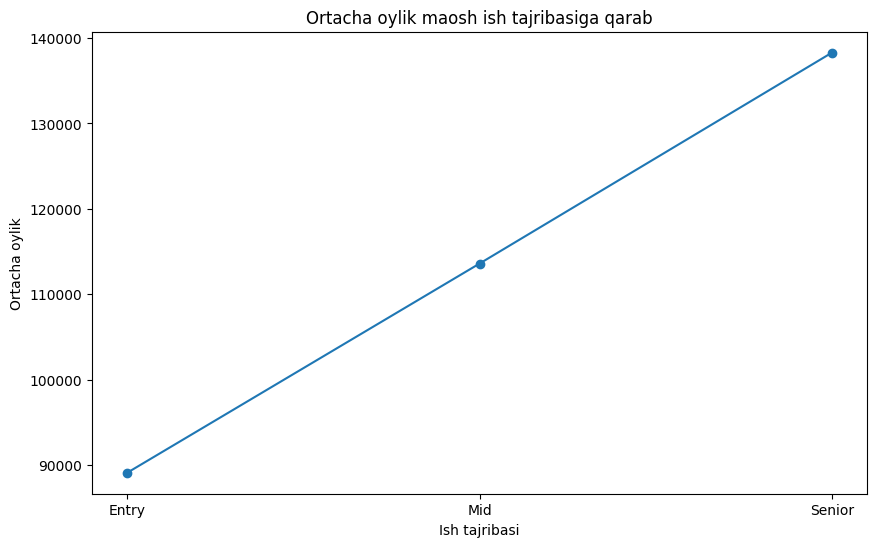

In [104]:
import matplotlib.pyplot as plt

exp_salary = df.groupby('experience_level')['salary'].mean()

plt.figure(figsize=(10,6))

plt.plot(exp_salary.index, exp_salary.values, marker='o')

plt.title('Ortacha oylik maosh ish tajribasiga qarab')
plt.xlabel('Ish tajribasi')
plt.ylabel('Ortacha oylik')

plt.show()

In [ ]:
"""
Bu yerda Level of degree qarab o'rtacha oylik line ko'rinishida berilgan
"""

"\nBu yerda Transaction Amount Distribution holatida bizda x-o'qida \nbu summa intervali, y-o'qida esa bizda nechi marta transaction bo'lganligidir.\nBu yerda 0-5000 gacha transactionlar soni ancha yuqori bo'lganligi ko'rinadi\n\n\n"

# Saborn with klib 

In [78]:
import seaborn as sns 

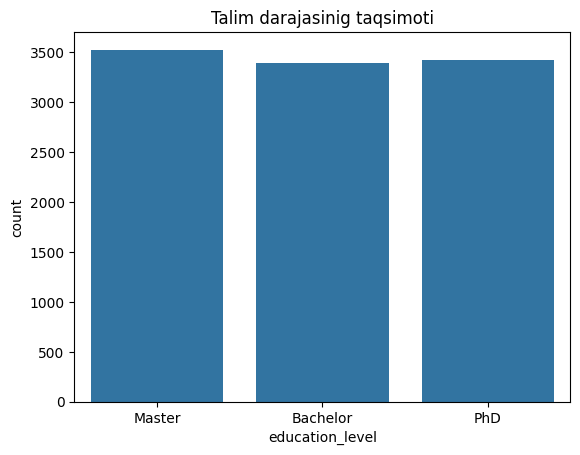

In [105]:
sns.countplot(x=df['education_level'])

plt.title('Talim darajasinig taqsimoti')    

plt.show()

In [ ]:
"""
Bu yerda esa biz seaborn bilan education level distribution ni ko'rdik; Master, bachelor va PhD lar sonini ko'rishimiz mumkin.
"""

"\nBu yerda esa biz seaborn bilan Channel va Transaaction Amount solishtirdik sababi \nsababi qaysi usullar bilan ular transaction qilishgan uchala holatdan ATMda ko'proq \ntransaction qilingani ko'rinib turibdi.\n\n\n"

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   AccountID            50000 non-null  float64
 1   TransactionAmount    50000 non-null  float64
 2   TransactionDate      50000 non-null  float64
 3   TransactionType      50000 non-null  int64  
 4   Location             50000 non-null  float64
 5   Channel              50000 non-null  float64
 6   CustomerAge          50000 non-null  float64
 7   CustomerOccupation   50000 non-null  float64
 8   TransactionDuration  50000 non-null  float64
 9   LoginAttempts        50000 non-null  float64
 10  AccountBalance       50000 non-null  float64
dtypes: float64(10), int64(1)
memory usage: 4.2 MB


# Plotly Express


In [107]:
import plotly.express as px

fig = px.bar(
    df,
    x='years_experience',
    y='salary',
    color='experience_level',
    hover_data=['education_level','company_size'],
    title='Experience va Salary orasidagi bogliqlik'
)

fig.show()

In [ ]:
"""
Bu yerda esa biz plotly.express bilan years of experience va salary o'rtasidagi bo'glikni ko'rib chiqdik
bunda Entry, Mid, va Senior darajadagi ishchilarning yillik tajribasi bilan ularning yillik maoshlarini 
ko'rishimiz mumkin. 

"""